# The Frequency–Current (F–I) Curve

A neuron's **F–I curve** relates the amplitude of a sustained input current to its steady-state firing rate. It is one of the most basic characterizations of a neuron's excitability. Here we drive a population of identical HH neurons, each with a different constant current, and measure the firing rate of each.

In [1]:
import brainstate
import brainunit as u
import numpy as np
import matplotlib.pyplot as plt
import braincell

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A population of HH neurons

`braincell` cells are vectorized: building `HH(N)` creates `N` independent neurons that we can drive with an `N`-vector of currents in a single pass.

In [2]:
class HH(braincell.SingleCompartment):
    def __init__(self, size, solver='exp_euler'):
        super().__init__(size, V_th=20. * u.mV, solver=solver)
        self.na = braincell.ion.SodiumFixed(size, E=50. * u.mV)
        self.na.add(INa=braincell.channel.Na_HH1952(size))
        self.k = braincell.ion.PotassiumFixed(size, E=-77. * u.mV)
        self.k.add(IK=braincell.channel.K_HH1952(size))
        self.IL = braincell.channel.IL(size, E=-54.387 * u.mV,
                                       g_max=0.03 * (u.mS / u.cm ** 2))

## Sweep the input current

We sweep 11 current densities from 0 to 20 uA/cm^2. We simulate 600 ms and **discard the first 100 ms** as a warm-up so onset transients do not inflate the rate, then count spikes over the remaining 500 ms.

In [3]:
n_levels = 11
amplitudes = np.linspace(0., 20., n_levels)        # uA/cm^2
I = amplitudes * (u.uA / u.cm ** 2)

net = HH(n_levels)
net.init_state()

warmup = 100. * u.ms
total = 600. * u.ms

def step(t):
    with brainstate.environ.context(t=t):
        net.update(I)
    return t, net.spike.value

with brainstate.environ.context(dt=0.01 * u.ms):
    times = u.math.arange(0. * u.ms, total, brainstate.environ.get_dt())
    ts, spikes = brainstate.transform.for_loop(step, times)

mask = (ts >= warmup)
counts = np.asarray(u.math.sum(spikes[mask], axis=0))
rate = counts / float((total - warmup) / u.second)   # Hz
print('spike counts:', counts.astype(int).tolist())

spike counts: [15, 28, 35, 39, 42, 45, 48, 50, 53, 55, 56]


## Plot the F–I curve

Firing rate rises monotonically with input current — the signature of a Type-I/Type-II excitable membrane.

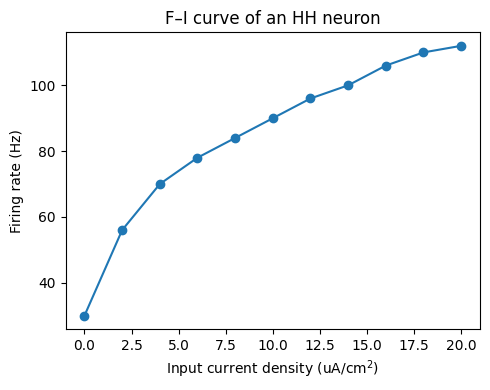

In [4]:
plt.figure(figsize=(5, 4))
plt.plot(amplitudes, rate, 'o-')
plt.xlabel('Input current density (uA/cm$^2$)')
plt.ylabel('Firing rate (Hz)')
plt.title('F\u2013I curve of an HH neuron')
plt.tight_layout()
plt.show()